# Task 1: Customer Churn Prediction using Logistic Regression
### Objective:
The goal of this task is to build a binary classification model to predict whether a customer will "Churn" (leave the service) based on their usage patterns and service details.

In [1]:
import pandas as pd 
df_train = pd.read_csv('churn-bigml-80.csv')
df_test = pd.read_csv('churn-bigml-20.csv')


## Data Loading
In this step, we load the pre-split datasets:
* **Train Set (80%):** Used to train the model.
* **Test Set (20%):** Used to evaluate the model performance.

In [2]:
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

### 2.1 Checking for Missing Values
Before proceeding to data preprocessing, it is essential to check for any missing or null values in the dataset. Missing data can negatively impact the performance of the Logistic Regression model.

Based on the initial inspection using `.info()`:
* The training set contains **2666** non-null entries for all columns.
* The testing set contains **667** non-null entries for all columns.

**Conclusion:** There are no missing values in this dataset, so no imputation is required.

In [10]:
print(df_train.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


## 2.2Data Preprocessing
In this stage, we prepare the raw data to be compatible with the Logistic Regression algorithm. 

### Steps taken:
1. **Label Encoding:** We convert binary categorical features ('International plan' and 'Voice mail plan') from strings ('Yes'/'No') to numerical values (1/0).
2. **Target Transformation:** The 'Churn' column is converted from Boolean (True/False) to Integer (1/0).
3. **Feature Selection:** We drop columns that do not contribute to the model's predictive power:
    * `State`: High cardinality (too many unique values).
    * `Area code`: A numerical identifier that doesn't have a statistical relationship with churning.

In [12]:
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

binary_mapping = {'Yes': 1, 'No': 0}
df_train_processed['International plan'] = df_train_processed['International plan'].map(binary_mapping)
df_train_processed['Voice mail plan'] = df_train_processed['Voice mail plan'].map(binary_mapping)

df_test_processed['International plan'] = df_test_processed['International plan'].map(binary_mapping)
df_test_processed['Voice mail plan'] = df_test_processed['Voice mail plan'].map(binary_mapping)

df_train_processed['Churn'] = df_train_processed['Churn'].astype(int)
df_test_processed['Churn'] = df_test_processed['Churn'].astype(int)

In [13]:
drop_cols = ['State', 'Area code']
X_train = df_train_processed.drop(['Churn'] + drop_cols, axis=1)
y_train = df_train_processed['Churn']

X_test = df_test_processed.drop(['Churn'] + drop_cols, axis=1)
y_test = df_test_processed['Churn']

In [14]:
print("Shape of X_train:", X_train.shape)
X_train.head()

Shape of X_train: (2666, 17)


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


### 2.3 Outlier Analysis (Customer Service Calls)
After performing a statistical check using the **IQR (Interquartile Range)** method on the `Customer service calls` feature, we found the following:

* **Upper Bound:** 3.5 calls.
* **Outliers Detected:** 210 customers (Those who called more than 3 times).
* **Maximum Observation:** 9 calls.

**Statistical Conclusion:**
In many datasets, outliers are removed to avoid noise. However, in **Churn Prediction**, these 210 outliers are "Natural Extremes" that represent highly dissatisfied customers. 

**Decision:**
We decided to **keep these outliers** in the dataset. A customer calling support 4 to 9 times is a strong indicator of potential churn. Removing them would hide the most critical patterns the model needs to learn.

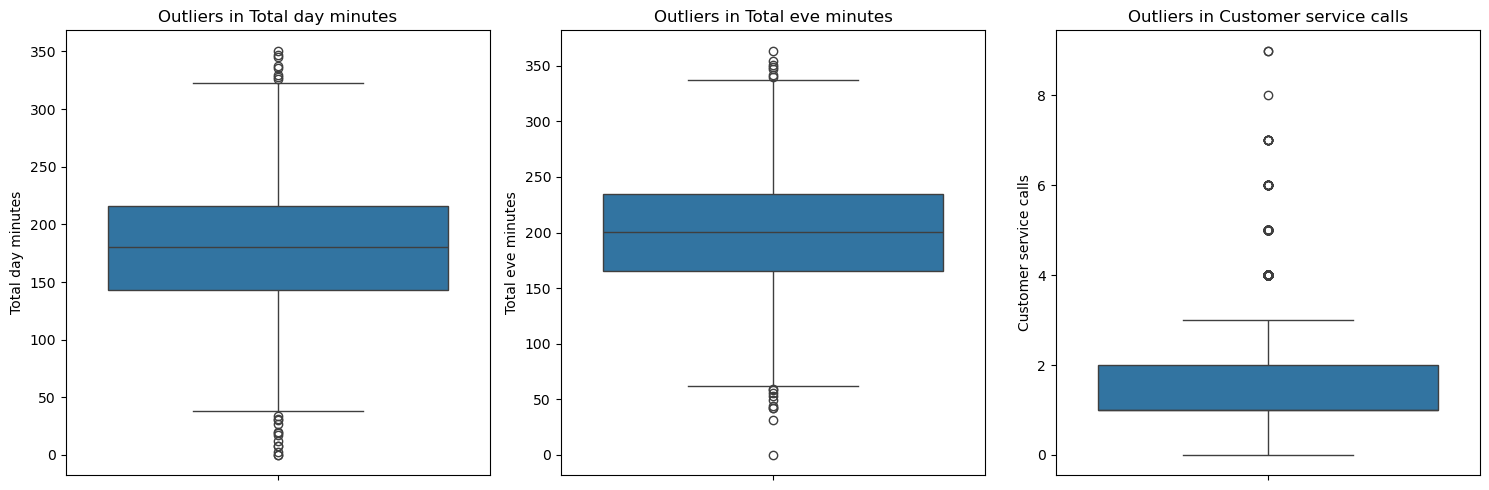

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_check = ['Total day minutes', 'Total eve minutes', 'Customer service calls']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_train[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [17]:
Q1 = df_train['Customer service calls'].quantile(0.25)
Q3 = df_train['Customer service calls'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_train[(df_train['Customer service calls'] < lower_bound) | (df_train['Customer service calls'] > upper_bound)]

print(f"Number of outliers in Service Calls: {len(outliers)}")
print(f"Upper bound for normal calls: {upper_bound}")

Number of outliers in Service Calls: 210
Upper bound for normal calls: 3.5


## 3. Model Training & Evaluation
In this section, we initialize the **Logistic Regression** model and train it using the training dataset (`X_train`, `y_train`). 

After training, we use the model to predict outcomes for the testing dataset (`X_test`). We will evaluate the performance using:
1. **Accuracy Score:** To measure the percentage of correct predictions.
2. **Confusion Matrix:** To visualize the True Positives, True Negatives, False Positives, and False Negatives.
3. **Classification Report:** To check Precision, Recall, and F1-Score.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
print(f" Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

 Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       572
           1       0.36      0.77      0.49        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667

